# Exploration Notebook

This notebook documents my first steps into trying out ALRNN's

## Import and Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# 1. Functional RNN logic and training loop from rnn_model.py
from rnn_model import PLRNN, train_multitask, evaluate_model

# 2. Dataset and padding logic from Dataset.py
from Dataset import MultiTaskDataset, collate_fn

# 3. Specific task-list creation and parameters from train_models.py
from train_models import create_tasks, train_and_evaluate, DURATION_PARAMS_SIMPLE

# 4. Math stability logic from MAR.py
from MAR import regularization_loss

if torch.backends.mps.is_available():
    device = 'mps'

# Set device to CPU because faster for small models
device = 'cpu'
print(device)

cpu


## Help functions

In [2]:
def plot_training_overview(results, title_override=None):
    """
    Generates a comprehensive 3-panel dashboard for training dynamics.
    
    Args:
        results (dict): The results dictionary output by train_and_evaluate.
        title_override (str, optional): Custom title for the figure.
    """
    # 1. Extract Data
    epochs = range(1, len(results['train_loss_history']) + 1)
    train_loss = results['train_loss_history']
    test_loss = results.get('test_loss_history', [])
    
    # Calculate Mean Accuracy per epoch across all tasks
    task_names = list(results['test_accuracies_history'].keys())
    
    # Helper to get mean over all tasks for a specific epoch list
    def get_mean_acc_history(acc_dict):
        # Transpose dict of lists to list of means
        if not acc_dict: return []
        n_epochs = len(list(acc_dict.values())[0])
        means = []
        for i in range(n_epochs):
            epoch_vals = [acc_dict[t][i] for t in task_names]
            means.append(np.mean(epoch_vals))
        return means

    train_mean_acc = get_mean_acc_history(results.get('train_accuracies', {}))
    test_mean_acc = get_mean_acc_history(results.get('test_accuracies_history', {}))

    # 2. Setup Figure
    fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
    run_title = title_override if title_override else f"Run: {results['run_id']} (L={results['L']})"
    fig.suptitle(run_title, fontsize=16, weight='bold')

    # --- Panel 1: Loss History ---
    ax = axes[0]
    ax.plot(epochs, train_loss, label='Train Loss', color='tab:blue', linewidth=2)
    if test_loss:
        ax.plot(epochs, test_loss, label='Test Loss', color='tab:orange', linestyle='--', linewidth=2)
    ax.set_title("Loss History")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log') # Log scale is usually better for MSE convergence

    # --- Panel 2: Mean Accuracy History ---
    ax = axes[1]
    if train_mean_acc:
        ax.plot(epochs, train_mean_acc, label='Mean Train Acc', color='tab:green', linewidth=2)
    if test_mean_acc:
        ax.plot(epochs, test_mean_acc, label='Mean Test Acc', color='tab:red', linestyle='--', linewidth=2)
    ax.set_title("Average Accuracy (All Tasks)")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='gray', linestyle=':', label='Chance (0.5)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # --- Panel 3: Individual Task Dynamics (Test) ---
    ax = axes[2]
    # Plot faint lines for all tasks to show spread
    for task in task_names:
        acc_history = results['test_accuracies_history'][task]
        ax.plot(epochs, acc_history, alpha=0.6, linewidth=1.5, label=task)
    
    # Highlight the mean trajectory in bold black
    if test_mean_acc:
        ax.plot(epochs, test_mean_acc, color='black', linewidth=3, linestyle=':', label='MEAN')

    ax.set_title("Individual Task Trajectories (Test)")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    
    # Put legend outside to avoid clutter
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    ax.grid(True, alpha=0.3)

    plt.show()

    # 3. Print Summary Card
    print(f"--- Summary: {results['run_id']} ---")
    print(f"Final Mean Test Accuracy: {results['mean_accuracy']:.2%}")
    print(f"Final Train Loss: {train_loss[-1]:.6f}")
    
    # Identify solved vs failed tasks (Arbitrary threshold > 90%)
    final_accs = results['test_accuracies']
    solved = [t for t, acc in final_accs.items() if acc > 0.90]
    failed = [t for t, acc in final_accs.items() if acc < 0.60]
    
    print(f"Solved Tasks (>90%): {len(solved)} / {len(task_names)}")
    if len(solved) < 11:
        print(f"Failing Tasks (<60%): {failed}")
    print("-" * 30)

## Model Training

In [ ]:
M = 64 # Number of hidden units
N = 3  # Output dimension (fixation, sin, cos)
params = DURATION_PARAMS_SIMPLE

In [5]:
configs = {
    "M": 64,
    "N": 64,
    "device": device,
    "num_epochs": 300
}

In [6]:
print("\n--- Experiment 1: Linear (L=0) ---")
_, results_lin = train_and_evaluate(
    M=M, L=0, N=N, duration_params=params, device='cpu',
    run_id=1, num_epochs=150
)

print("\n--- Experiment 1: Almost Linear (L=8) ---")
_, results_almost_lin = train_and_evaluate(
    M=M, L=8, N=N, duration_params=params, device='cpu',
    run_id=2, num_epochs=150
)

print("\n--- Experiment 2: Halflinear (L=32) ---")
_, results_half_lin = train_and_evaluate(
    M=M, L=32, N=N, duration_params=params, device='cpu',
    run_id=3, num_epochs=150
)

print("\n--- Experiment 2: Nonlinear (L=64) ---")
_, results_nonlin = train_and_evaluate(
    M=M, L=64, N=N, duration_params=params, device='cpu',
    run_id=4, num_epochs=150
)



--- Experiment 1: Linear (L=0) ---
Epoch 5/150, Loss: 0.6627, Test Loss: 0.6498, Test Acc: 37.28%
  Task 0 Train Acc: 16.21%, Test Acc: 12.24%
  Task 1 Train Acc: 18.53%, Test Acc: 13.25%
  Task 2 Train Acc: 18.28%, Test Acc: 18.81%
  Task 3 Train Acc: 14.61%, Test Acc: 20.65%
  Task 4 Train Acc: 48.83%, Test Acc: 52.50%
  Task 5 Train Acc: 45.88%, Test Acc: 56.98%
  Task 6 Train Acc: 43.58%, Test Acc: 53.57%
  Task 7 Train Acc: 42.21%, Test Acc: 43.56%
  Task 8 Train Acc: 15.52%, Test Acc: 18.68%
  Task 9 Train Acc: 20.35%, Test Acc: 19.78%
  Task 10 Train Acc: 100.00%, Test Acc: 100.00%
Epoch 10/150, Loss: 0.5629, Test Loss: 0.5626, Test Acc: 36.80%
  Task 0 Train Acc: 13.82%, Test Acc: 15.12%
  Task 1 Train Acc: 20.83%, Test Acc: 15.73%
  Task 2 Train Acc: 18.99%, Test Acc: 24.24%
  Task 3 Train Acc: 14.75%, Test Acc: 14.46%
  Task 4 Train Acc: 48.15%, Test Acc: 45.92%
  Task 5 Train Acc: 50.45%, Test Acc: 35.23%
  Task 6 Train Acc: 47.26%, Test Acc: 59.55%
  Task 7 Train Acc: 50.7

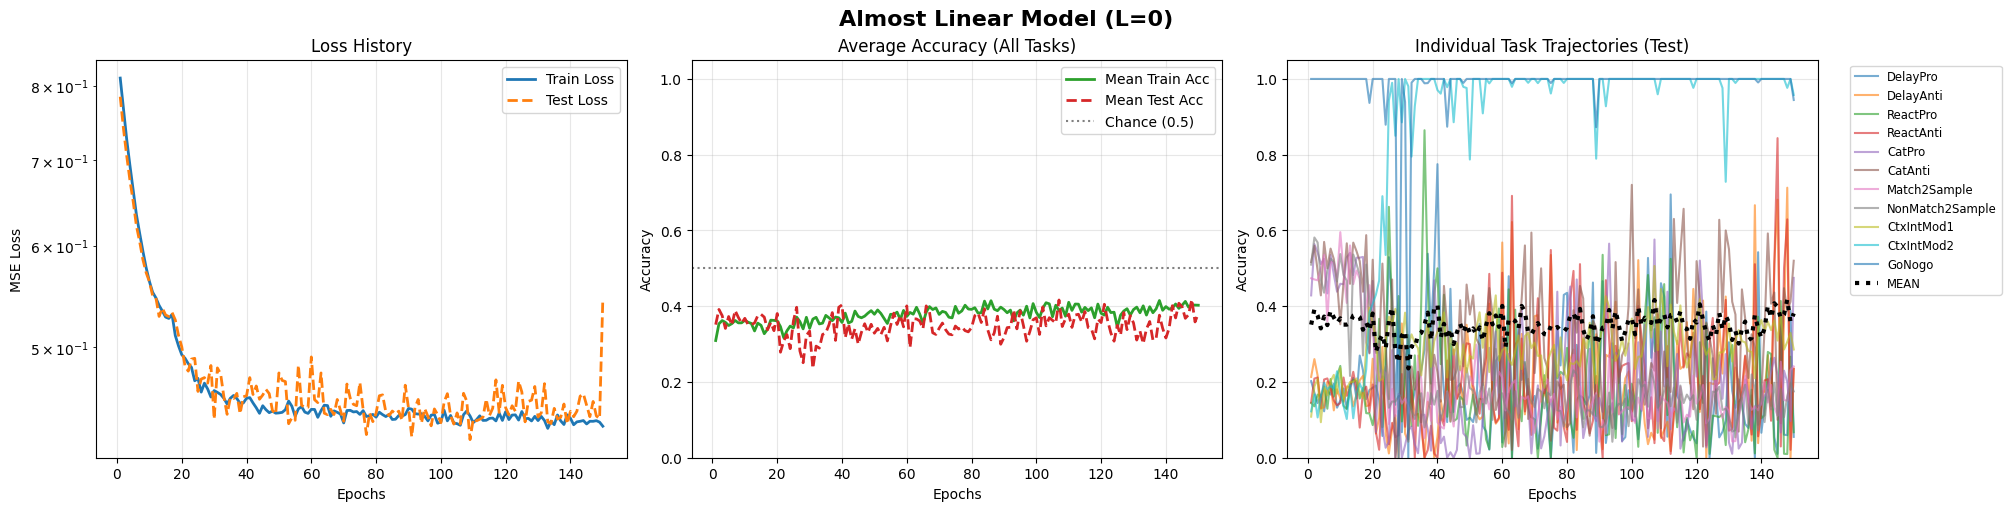

--- Summary: 1 ---
Final Mean Test Accuracy: 35.79%
Final Train Loss: 0.433781
Solved Tasks (>90%): 1 / 11
Failing Tasks (<60%): ['DelayPro', 'DelayAnti', 'ReactPro', 'ReactAnti', 'CatPro', 'CatAnti', 'Match2Sample', 'NonMatch2Sample', 'CtxIntMod1']
------------------------------


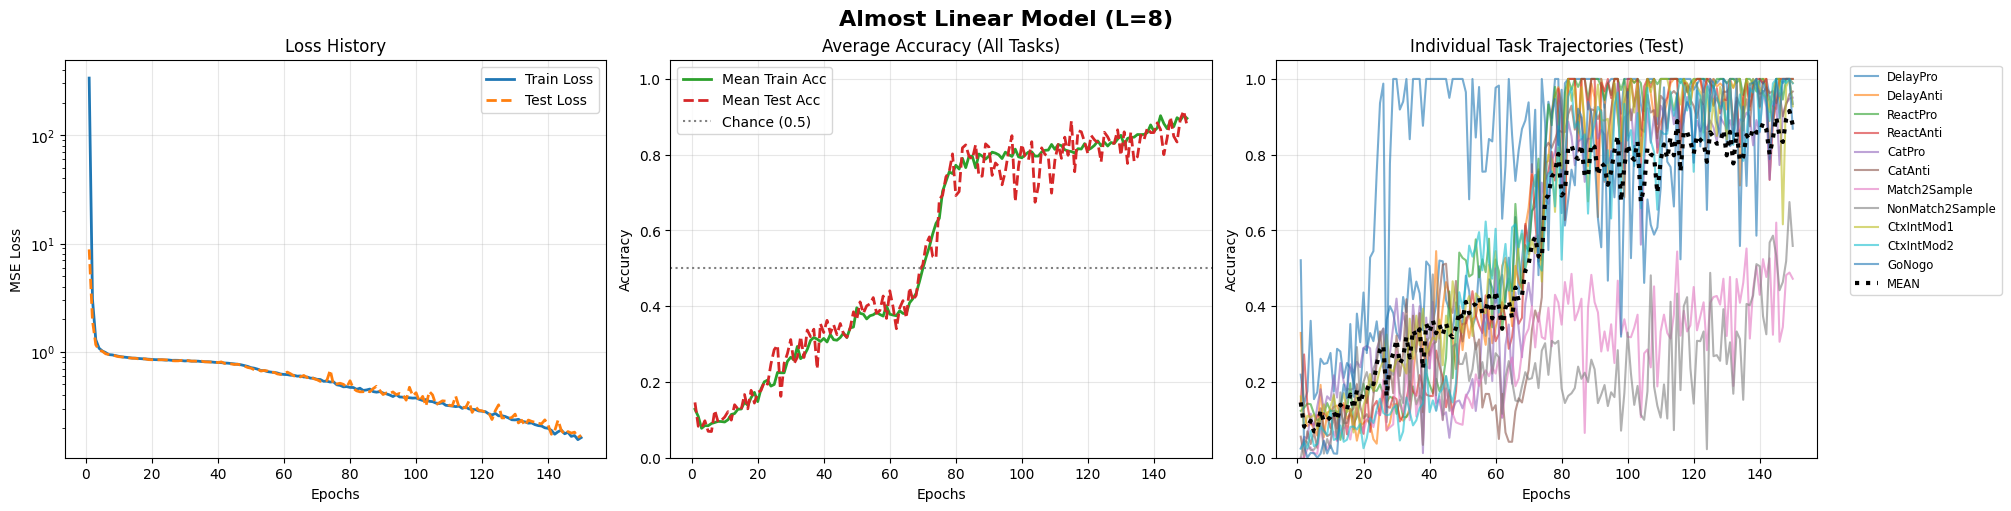

--- Summary: 2 ---
Final Mean Test Accuracy: 87.21%
Final Train Loss: 0.161711
Solved Tasks (>90%): 6 / 11
Failing Tasks (<60%): ['Match2Sample', 'NonMatch2Sample']
------------------------------


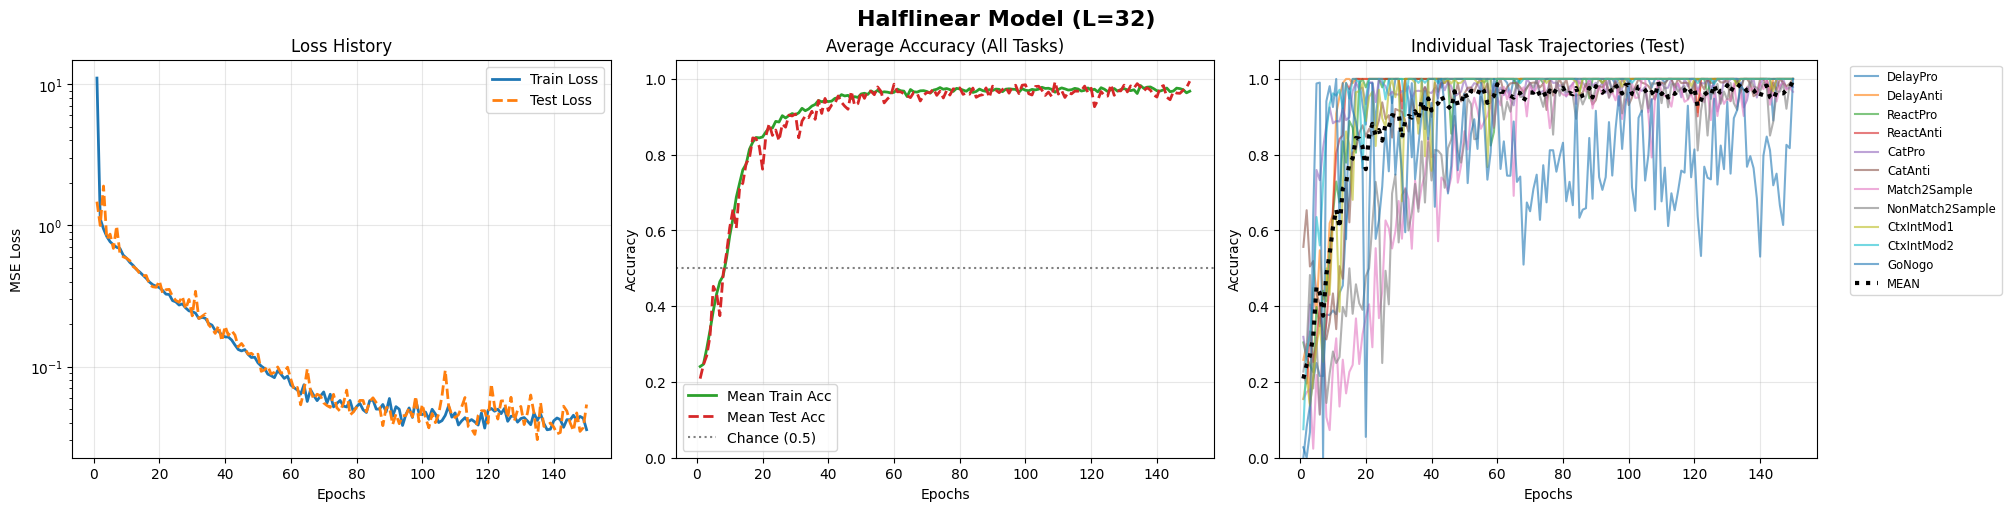

--- Summary: 3 ---
Final Mean Test Accuracy: 99.50%
Final Train Loss: 0.035756
Solved Tasks (>90%): 11 / 11
------------------------------


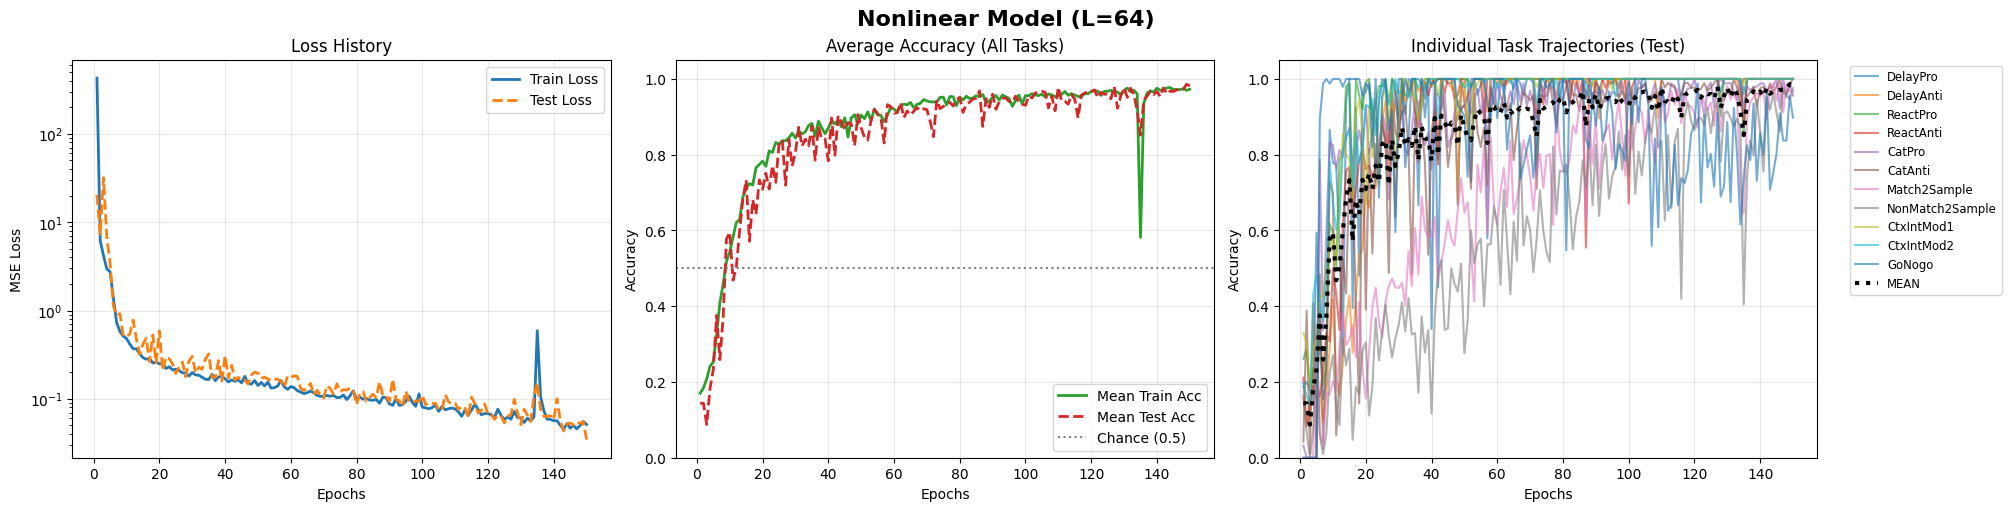

--- Summary: 4 ---
Final Mean Test Accuracy: 97.25%
Final Train Loss: 0.051291
Solved Tasks (>90%): 10 / 11
Failing Tasks (<60%): []
------------------------------


In [7]:
plot_training_overview(results_lin, title_override="Almost Linear Model (L=0)")

plot_training_overview(results_almost_lin, title_override="Almost Linear Model (L=8)")

plot_training_overview(results_half_lin, title_override="Halflinear Model (L=32)")

plot_training_overview(results_nonlin, title_override="Nonlinear Model (L=64)")
